In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, Normalizer

# Load dataset
data = pd.read_csv('Dataset(2).csv')

# Set options for displaying data
pd.set_option('display.max_columns', None)

C:\Users\taiyo\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (22,32) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [2]:
# Data Cleaning

In [3]:
# Data Pre-processing
# Drop unnessesary culumns ex. ID ect...
data.drop(['Permit Number', 'Record ID', 'Street Number Suffix', 'TIDF Compliance', 'Unit Suffix', 'Unit', 'Location'], axis = 1, inplace = True)

# There are only 2 original data Nan and Y, so I replace NaN to N
data['Structural Notification'] = data['Structural Notification'].fillna('N')
data['Voluntary Soft-Story Retrofit'] = data['Voluntary Soft-Story Retrofit'].fillna('N')
data['Fire Only Permit'] = data['Fire Only Permit'].fillna('N')
data['Site Permit'] = data['Site Permit'].fillna('N')

# Drop NaN value
data.dropna(subset=['Street Suffix'], inplace=True)
data.dropna(subset=['Issued Date'], inplace=True)
data.dropna(subset=['Completed Date'], inplace=True)
data.dropna(subset=['First Construction Document Date'], inplace=True)
data.dropna(subset=['Description'], inplace=True)
data.dropna(subset=['Permit Expiration Date'], inplace=True)

# Replace Nan value to mean of dataset
mean_value_NoES = data['Number of Existing Stories'].mean()
data['Number of Existing Stories'].fillna(mean_value_NoES, inplace=True)
mean_value_NoPS = data['Number of Proposed Stories'].mean()
data['Number of Proposed Stories'].fillna(mean_value_NoPS, inplace=True)
data['Estimated Cost'].interpolate(method = 'linear', inplace = True)
mean_value_RC = data['Revised Cost'].mean()
data['Revised Cost'].fillna(mean_value_RC, inplace = True)

# Interpolate missing values in the 'Plansets' column using linear interpolation
data['Plansets'].interpolate(method = 'linear', inplace = True)

# Drop rows with missing values in the 'Zipcode' column
data.dropna(subset=['Zipcode'], inplace=True)

# Convert 'Zipcode' column to integer type
data['Zipcode'] = data['Zipcode'].astype(int)

# Generate 'Address' column combining 'Lot', 'Block', 'Street Number', 'Street Name', 'Street Suffix', and 'Zipcode'
data['Address'] = 'Lot ' + data['Lot'].astype(str) + ', Block ' + data['Block'].astype(str) + ', ' + data['Street Number'].astype(str) + ' ' + data['Street Name'] + ' ' + data['Street Suffix'] + ', ' + data['Zipcode'].astype(str)


In [4]:
# Remove '.0' from the 'Address' column
data['Address'] = data['Address'].str.replace('.0', '', regex=False)

# Drop rows with missing values in specific columns
data.dropna(subset=['Existing Construction Type'], inplace=True)
data.dropna(subset=['Existing Construction Type Description'], inplace=True)
data.dropna(subset=['Proposed Construction Type'], inplace=True)
data.dropna(subset=['Proposed Construction Type Description'], inplace=True)

# Fill missing values in 'Supervisor District' and 'Neighborhoods - Analysis Boundaries' with mode
mode_value_SD = data['Supervisor District'].mode()[0]
data['Supervisor District'].fillna(mode_value_SD, inplace=True)
mode_value_NAB = data['Neighborhoods - Analysis Boundaries'].mode()[0]
data['Neighborhoods - Analysis Boundaries'].fillna(mode_value_NAB, inplace=True)

# Drop unnecessary columns
columns_to_drop = ['Lot', 'Block', 'Street Number', 'Street Name', 'Street Suffix', 'Zipcode']
data.drop(columns=columns_to_drop, axis=1, inplace=True)

In [5]:
# Initialize LabelEncoder
le = LabelEncoder()

# Encode categorical columns 'Existing Use' and 'Proposed Use'
for column in ['Existing Use', 'Proposed Use']:
    data[column] = le.fit_transform(data[column])

# Rename columns
data.rename(columns={'Existing Use': 'Existing_Use', 'Proposed Use': 'Proposed_Use', 'Existing Units': 'Existing_Units', 'Proposed Units': 'Proposed_Units'}, inplace=True)

# Fill missing values with median
data['Existing_Use'].fillna(value=data['Existing_Use'].median(), inplace=True)
data['Proposed_Use'].fillna(value=data['Proposed_Use'].median(), inplace=True)
data['Existing_Units'].fillna(value=data['Existing_Units'].median(), inplace=True)
data['Proposed_Units'].fillna(value=data['Proposed_Units'].median(), inplace=True)


In [6]:
# Data Exploration

In [7]:
# - Data analyse

In [8]:
# descriptive statistics for the dataset
data.describe()

,Permit Type,Number of Existing Stories,Number of Proposed Stories,Estimated Cost,Revised Cost,Existing_Use,Existing_Units,Proposed_Use,Proposed_Units,Plansets,Existing Construction Type,Proposed Construction Type,Supervisor District
count,91691.000000,91691.000000,91691.000000,9.169100e+04,9.169100e+04,91691.000000,91691.000000,91691.000000,91691.000000,91691.000000,91691.000000,91691.000000,91691.000000
mean,7.747402,5.811648,5.823287,5.736077e+04,6.608982e+04,17.435026,14.572273,17.187968,14.626790,1.196290,4.083018,4.082767,5.580602
std,1.095109,8.671430,8.667471,4.247714e+05,4.189073e+05,24.723049,70.359143,24.409785,70.410364,29.735118,1.586397,1.586455,2.852515
min,2.000000,0.000000,0.000000,1.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,8.000000,2.000000,2.000000,3.200000e+03,4.000000e+03,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,3.000000,3.000000
50%,8.000000,3.000000,3.000000,1.000000e+04,1.200000e+04,7.000000,1.000000,7.000000,1.000000,2.000000,5.000000,5.000000,6.000000
75%,8.000000,4.000000,4.000000,3.000000e+04,3.500000e+04,32.000000,3.000000,32.000000,3.000000,2.000000,5.000000,5.000000,8.000000
max,8.000000,63.000000,63.000000,6.200000e+07,6.200000e+07,90.000000,1907.000000,90.000000,1911.000000,9000.000000,5.000000,5.000000,11.000000


In [9]:
# Display concise summary of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 91691 entries, 3 to 198715
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Permit Type                             91691 non-null  int64  
 1   Permit Type Definition                  91691 non-null  object 
 2   Permit Creation Date                    91691 non-null  object 
 3   Description                             91691 non-null  object 
 4   Current Status                          91691 non-null  object 
 5   Current Status Date                     91691 non-null  object 
 6   Filed Date                              91691 non-null  object 
 7   Issued Date                             91691 non-null  object 
 8   Completed Date                          91691 non-null  object 
 9   First Construction Document Date        91691 non-null  object 
 10  Structural Notification                 91691 non-null  o

In [10]:
# - Data Manipulation

In [11]:
# Data Type Conversion

# Convert float to int type to reduce calculation cost for future actions.
data['Number of Existing Stories'] = data['Number of Existing Stories'].astype(int)
data['Number of Proposed Stories'] = data['Number of Proposed Stories'].astype(int)
data['Estimated Cost'] = data['Estimated Cost'].astype(int)
data['Revised Cost'] = data['Revised Cost'].astype(int)
data['Existing_Units'] = data['Existing_Units'].astype(int)
data['Proposed_Units'] = data['Proposed_Units'].astype(int)
data['Plansets'] = data['Plansets'].astype(int)
data['Existing Construction Type'] = data['Existing Construction Type'].astype(int)
data['Proposed Construction Type'] = data['Proposed Construction Type'].astype(int)
data['Supervisor District'] = data['Supervisor District'].astype(int)

# Apply corrected date format and function to calculate Duration_of_project
def convert_dates_and_calculate_duration(df):
    # Convert to datetime and change the format to '%Y-%m-%d'
    columns_to_convert = [
        'Permit Creation Date', 'Current Status Date', 'Filed Date', 'Issued Date',
        'Completed Date', 'First Construction Document Date', 'Permit Expiration Date'
    ]
    for column in columns_to_convert:
        data[column] = pd.to_datetime(data[column], errors='coerce')  # Convert to datetime, invalid data will be NaT

    # Calculate 'Duration_of_project' and add as a new column (calculated in days)
    data['Duration_of_project'] = (data['Completed Date'] - data['Issued Date']).dt.days
    
    return df

data = convert_dates_and_calculate_duration(data)

In [12]:
# Visualizing data

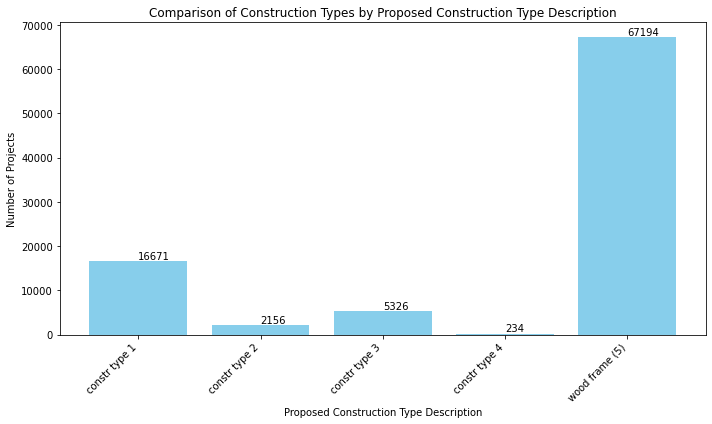

In [13]:
# Case 1: Construction status is 'complete' and construction type comparison.
# Filtering projects that meet the conditions
filtered_projects = data[(data['Current Status'] == 'complete') &
                       (data['Proposed Construction Type Description'].isin(['wood frame (5)', 'constr type 3', 'constr type 1', 'constr type 4', 'constr type 2']))]

# Counting the number of projects for each category
counts = filtered_projects.groupby('Proposed Construction Type Description')['Permit Type Definition'].count()

# Creating the graph
plt.figure(figsize=(10, 6))
bars = plt.bar(counts.index, counts.values, color='skyblue')

# Plotting the values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom')

plt.xlabel('Proposed Construction Type Description')
plt.ylabel('Number of Projects')
plt.title('Comparison of Construction Types by Proposed Construction Type Description')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


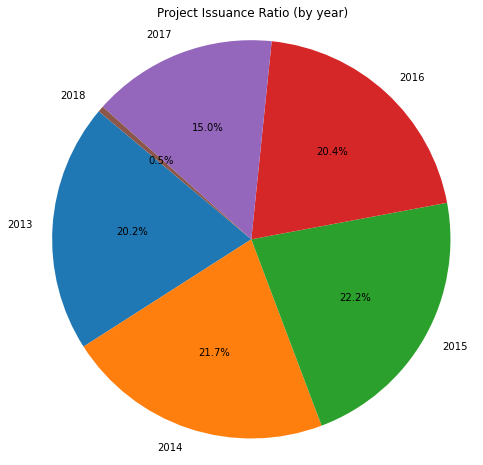

In [14]:
# Case 2: Number of projects per year
# Extract the year from the 'Issued Date' column directly
years = data['Issued Date'].dt.year.dropna().astype(int)

# Count projects per year
project_counts = years.value_counts().sort_index()

# Calculate ratios
total_projects = project_counts.sum()
project_ratios = project_counts / total_projects

# Plot
plt.figure(figsize=(8, 8))
plt.pie(project_ratios, labels=project_ratios.index, autopct='%1.1f%%', startangle=140)
plt.title('Project Issuance Ratio (by year)')
plt.axis('equal')  # Keep the aspect ratio so that the pie chart is circular
plt.show()

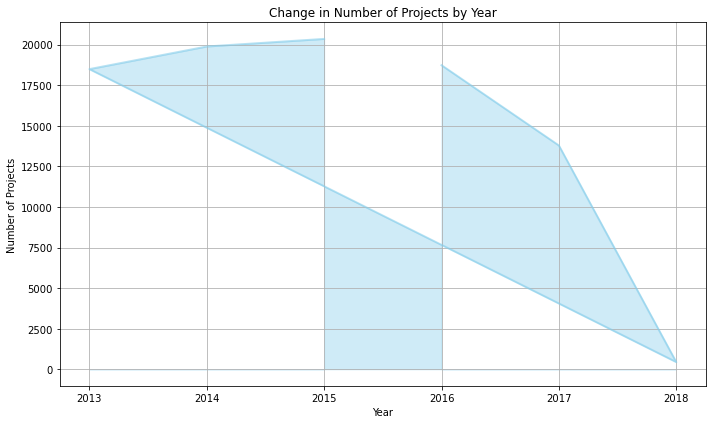

In [15]:
# Case 3: Number of projects per year (2)
# Count the number of projects for each year
project_counts = {year: years.eq(year).sum() for year in set(years)}

# Create the graph
plt.figure(figsize=(10, 6))
plt.fill_between(list(project_counts.keys()), list(project_counts.values()), color='skyblue', alpha=0.4)
plt.plot(list(project_counts.keys()), list(project_counts.values()), color='skyblue', alpha=0.6, linewidth=2)
plt.xlabel('Year')
plt.ylabel('Number of Projects')
plt.title('Change in Number of Projects by Year')
plt.xticks(list(project_counts.keys()))
plt.grid(True)
plt.tight_layout()
plt.show()

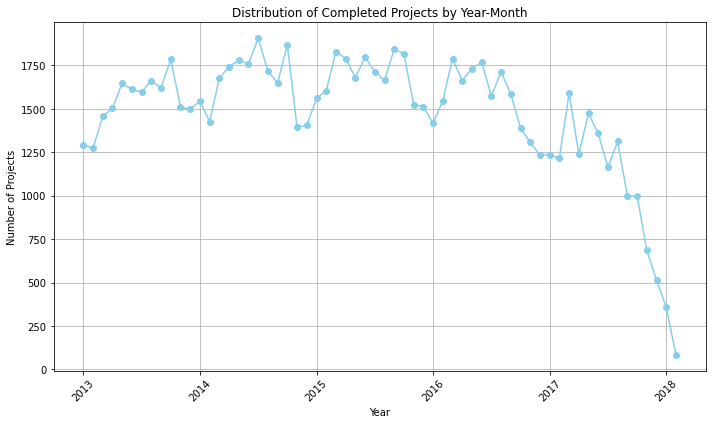

In [16]:
# Case 4: Number of projects by month period
# Extract projects under specific conditions
filtered_projects = data[data['Current Status'] == 'complete']

# Extract year and month of completed projects
issued_dates = pd.to_datetime(filtered_projects['Issued Date'])
year_month = issued_dates.dt.to_period('M')

# Count projects per month
project_counts_by_month = year_month.value_counts().sort_index()

# Get the index of the first month with data for each year
unique_years = year_month.dt.year.unique()
yearly_ticks = [str(year) + '-01' for year in unique_years]
yearly_tick_positions = [project_counts_by_month.index.get_loc(pd.Period(yt, freq='M')) for yt in yearly_ticks]

# Create a line histogram
plt.figure(figsize=(10, 6))
plt.plot(project_counts_by_month.index.astype(str), project_counts_by_month.values, color='skyblue', marker='o', linestyle='-')
plt.xlabel('Year')
plt.ylabel('Number of Projects')
plt.title('Distribution of Completed Projects by Year-Month')

# Set X-axis ticks for each year
plt.xticks(ticks=yearly_tick_positions, labels=unique_years, rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

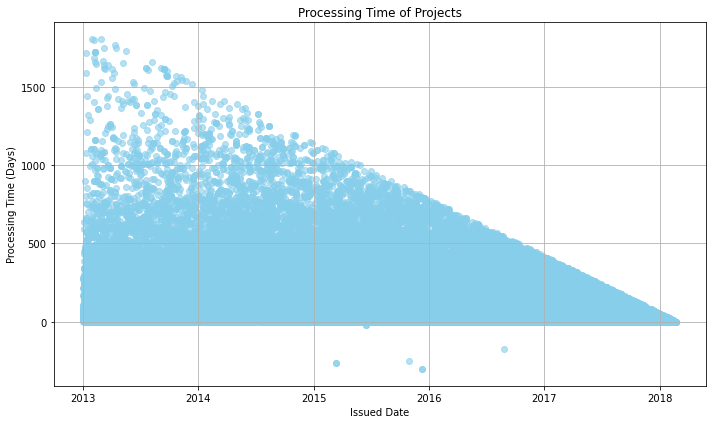

In [17]:
# Case 5: Time required to complete construction
# Calculate the difference between the application date and the issuance date
issued_date = pd.to_datetime(data['Issued Date'])
complete_date = pd.to_datetime(data['Completed Date'])
processing_time = (complete_date - issued_date).dt.days  # Get the duration in days

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(issued_date, processing_time, color='skyblue', alpha=0.6)
plt.xlabel('Issued Date')
plt.ylabel('Processing Time (Days)')
plt.title('Processing Time of Projects')
plt.grid(True)
plt.tight_layout()
plt.show()

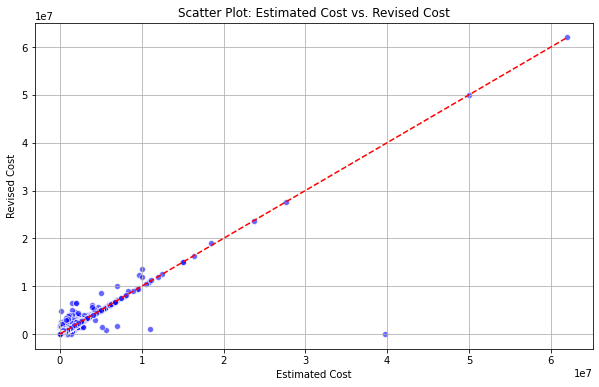

In [18]:
# Case 6: Relationship between Estimated Cost and Revised Cost
# Plotting the relationship between "Estimated Cost" and "Revised Cost" using a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(data['Estimated Cost'], data['Revised Cost'], color='blue', alpha=0.6, edgecolors='w')

# Adding title and axis labels to the plot
plt.title('Scatter Plot: Estimated Cost vs. Revised Cost')
plt.xlabel('Estimated Cost')
plt.ylabel('Revised Cost')

# Drawing a line to identify equal costs (for identifying outliers)
plt.plot([0, max(data['Estimated Cost'])], [0, max(data['Estimated Cost'])], color='red', linestyle='--')

# Displaying the grid
plt.grid(True)

# Showing the plot
plt.show()

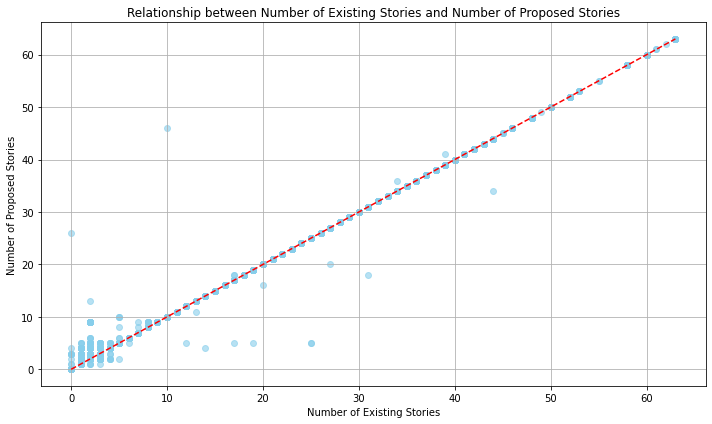

In [19]:
# Case 7: Relationship between Number of Existing Stories and Number of Proposed Stories
# Scatter plot creation
plt.figure(figsize=(10, 6))
plt.scatter(data['Number of Existing Stories'], data['Number of Proposed Stories'], color='skyblue', alpha=0.6)
plt.xlabel('Number of Existing Stories')
plt.ylabel('Number of Proposed Stories')
plt.title('Relationship between Number of Existing Stories and Number of Proposed Stories')

# Add a line to identify equal stories
plt.plot([0, max(data['Number of Existing Stories'])], [0, max(data['Number of Existing Stories'])], color='red', linestyle='--')

plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# Data transformation

In [21]:
# Label Encording
for column in ['Permit Type Definition', 'Permit Creation Date', 'Description', 'Current Status','Current Status Date', 'Filed Date', 'Issued Date','Completed Date', 'First Construction Document Date', 'Structural Notification', 'Voluntary Soft-Story Retrofit', 'Fire Only Permit', 'Permit Expiration Date', 'Existing Construction Type Description', 'Proposed Construction Type Description', 'Site Permit', 'Neighborhoods - Analysis Boundaries', 'Address']:
    data[column] = le.fit_transform(data[column])

In [22]:
# Data Scaling and Normalization
# Save the original column names
original_columns = data.columns.tolist()

# Min-Max Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Standardization
scaler = StandardScaler()
standardized_data = scaler.fit_transform(data)

# Normalization
scaler = Normalizer()
normalized_data = scaler.fit_transform(data)

# Convert scaled and normalized data back to DataFrame and reset the original column names
scaled_data = pd.DataFrame(scaled_data, columns=original_columns)
standardized_data = pd.DataFrame(standardized_data, columns=original_columns)
normalized_data = pd.DataFrame(normalized_data, columns=original_columns)

In [23]:
scaled_data.head(2)

,Permit Type,Permit Type Definition,Permit Creation Date,Description,Current Status,Current Status Date,Filed Date,Issued Date,Completed Date,First Construction Document Date,Structural Notification,Number of Existing Stories,Number of Proposed Stories,Voluntary Soft-Story Retrofit,Fire Only Permit,Permit Expiration Date,Estimated Cost,Revised Cost,Existing_Use,Existing_Units,Proposed_Use,Proposed_Units,Plansets,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Address,Duration_of_project
0,1.0,1.0,0.750583,0.616953,0.25,0.886923,0.750389,0.884227,0.886836,0.884137,0.0,0.031746,0.031746,0.0,0.0,0.683881,0.000032,0.000032,0.000000,0.000524,0.000000,0.000523,0.000222,1.0,1.0,1.0,1.0,0.0,0.2,0.500,0.280094,0.146515
1,1.0,1.0,0.875680,0.485623,0.25,0.880769,0.875583,0.875680,0.880677,0.875583,0.0,0.047619,0.047619,0.0,0.0,0.674491,0.000194,0.000194,0.077778,0.002622,0.077778,0.002616,0.000000,1.0,1.0,1.0,1.0,0.0,0.4,0.275,0.481616,0.149360


In [24]:
standardized_data.head(2)

,Permit Type,Permit Type Definition,Permit Creation Date,Description,Current Status,Current Status Date,Filed Date,Issued Date,Completed Date,First Construction Document Date,Structural Notification,Number of Existing Stories,Number of Proposed Stories,Voluntary Soft-Story Retrofit,Fire Only Permit,Permit Expiration Date,Estimated Cost,Revised Cost,Existing_Use,Existing_Units,Proposed_Use,Proposed_Units,Plansets,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Address,Duration_of_project
0,0.230662,0.230656,1.117226,0.336240,-0.030538,1.246765,1.117091,1.576954,1.247051,1.574938,-0.178426,-0.439551,-0.441087,-0.013211,-0.382186,1.469196,-0.130331,-0.152994,-0.705217,-0.192901,-0.704146,-0.193535,0.027029,0.578031,0.578031,0.578168,0.578168,-0.100453,-0.904681,0.122348,-0.690308,-0.840906
1,0.230662,0.230656,1.587394,-0.130937,-0.030538,1.224144,1.587242,1.544868,1.224402,1.542817,-0.178426,-0.324229,-0.325712,-0.013211,-0.382186,1.426314,-0.106789,-0.129122,-0.422079,-0.136049,-0.417375,-0.136725,-0.040232,0.578031,0.578031,0.578168,0.578168,-0.100453,-0.203542,-0.603422,0.004029,-0.808168


In [25]:
normalized_data.head(2)

,Permit Type,Permit Type Definition,Permit Creation Date,Description,Current Status,Current Status Date,Filed Date,Issued Date,Completed Date,First Construction Document Date,Structural Notification,Number of Existing Stories,Number of Proposed Stories,Voluntary Soft-Story Retrofit,Fire Only Permit,Permit Expiration Date,Estimated Cost,Revised Cost,Existing_Use,Existing_Units,Proposed_Use,Proposed_Units,Plansets,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Address,Duration_of_project
0,0.000164,0.000041,0.019794,0.961075,0.000041,0.023626,0.019774,0.023319,0.023606,0.023298,0.0,0.000041,0.000041,0.0,0.0,0.026864,0.040982,0.040982,0.000000,0.000020,0.000000,0.000020,0.000041,0.000102,0.000082,0.000102,0.000082,0.0,0.000061,0.000410,0.263188,0.000123
1,0.000173,0.000043,0.024317,0.796555,0.000043,0.024705,0.024295,0.024317,0.024683,0.024295,0.0,0.000065,0.000065,0.0,0.0,0.027898,0.258916,0.258916,0.000151,0.000108,0.000151,0.000108,0.000000,0.000108,0.000086,0.000108,0.000086,0.0,0.000108,0.000237,0.476513,0.000259
